# 04 — Hypothesis Testing & Imbalanced Data Handling

Statistical hypothesis testing (H1–H7) for the bank marketing dataset, normality checks, and class-imbalance resampling strategies.

**Key constraints:**
- `duration` is **never** used in Set B (data-available-before-call features)
- Raw CSV loaded for hypothesis tests (string target `'yes'`/`'no'`)
- Significance level α = 0.05

## 1. Import Required Libraries

In [21]:
import sys
from pathlib import Path

# Ensure project root is on path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, mannwhitneyu, chi2_contingency, kruskal, f_oneway

from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

from src.data_loader import load_dataset
from src.features import get_feature_lists
from src.hypothesis_tests import chi_square_test, mann_whitney_test, run_all_hypothesis_tests
from src.imbalance import get_resampler, compare_resampling_strategies
from src.preprocessing import build_preprocessing_pipeline

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
print("Project root:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("Libraries loaded ✓")

Project root: /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project
RAW_DIR: /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/data/raw
Libraries loaded ✓


## 2. Load and Explore Dataset

In [22]:
# Load raw CSV — keep string target ('yes'/'no') for hypothesis tests
df_raw = pd.read_csv(RAW_DIR / "bank-additional-full.csv", sep=";")
print(f"Shape: {df_raw.shape}")
print(f"\nDtypes:\n{df_raw.dtypes}")
print(f"\nBasic stats (numeric cols):")
display(df_raw.describe())

# Target distribution
print(f"\nTarget distribution:")
print(df_raw["y"].value_counts())
print(f"Positive rate: {(df_raw['y']=='yes').mean():.1%}")

Shape: (41188, 21)

Dtypes:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Basic stats (numeric cols):


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.0000,41188.0000,41188.0000,41188.0000,41188.0000,41188.0000,41188.0000,41188.0000,41188.0000,41188.0000
mean,40.0241,258.2850,2.5676,962.4755,0.1730,0.0819,93.5757,-40.5026,3.6213,5167.0359
std,10.4212,259.2792,2.7700,186.9109,0.4949,1.5710,0.5788,4.6282,1.7344,72.2515
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,4963.6000
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,5099.1000
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,5191.0000
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,5228.1000
max,98.0000,4918.0000,56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,5228.1000



Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64
Positive rate: 11.3%


## 3. Handle Missing Values

In [23]:
# Detect missing values
missing = df_raw.isnull().sum()
pct_missing = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "pct": pct_missing})
missing_df = missing_df[missing_df["missing_count"] > 0]

if missing_df.empty:
    print("✓ No explicit NaN values detected.")
else:
    display(missing_df)

# The bank-additional dataset encodes unknowns as the string 'unknown'
unknown_counts = (df_raw == "unknown").sum()
unknown_df = unknown_counts[unknown_counts > 0].rename("unknown_count").to_frame()
unknown_df["pct"] = (unknown_df["unknown_count"] / len(df_raw) * 100).round(2)
print("\n'unknown' placeholder counts by column:")
display(unknown_df)

# Strategy: keep 'unknown' as a valid category for categorical features
# (captured by the categorical pipeline's OneHotEncoder)
print("\nStrategy: treat 'unknown' as a distinct category — no rows dropped.")

✓ No explicit NaN values detected.

'unknown' placeholder counts by column:


,unknown_count,pct
job,330,0.8000
marital,80,0.1900
education,1731,4.2000
default,8597,20.8700
housing,990,2.4000
loan,990,2.4000



Strategy: treat 'unknown' as a distinct category — no rows dropped.


## 4. Detect and Handle Imbalanced Data

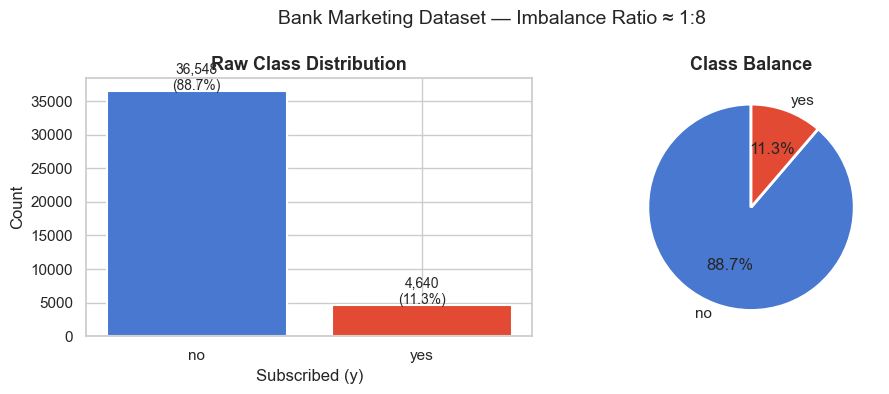


Positive rate: 11.27% → severe class imbalance


In [24]:
# ── Class distribution visualisation ─────────────────────────────────────────
y_counts = df_raw["y"].value_counts()
pos_rate = y_counts["yes"] / len(df_raw)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ["#4878CF", "#E24A33"]
axes[0].bar(y_counts.index, y_counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Raw Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Subscribed (y)")
axes[0].set_ylabel("Count")
for i, (label, cnt) in enumerate(y_counts.items()):
    axes[0].text(i, cnt + 100, f"{cnt:,}\n({cnt/len(df_raw):.1%})", ha="center", fontsize=10)

# Pie chart
axes[1].pie(y_counts.values, labels=y_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Balance", fontsize=13, fontweight="bold")

plt.suptitle(f"Bank Marketing Dataset — Imbalance Ratio ≈ 1:{int(1/pos_rate):.0f}", fontsize=14)
plt.tight_layout()
plt.show()
print(f"\nPositive rate: {pos_rate:.2%} → severe class imbalance")

In [25]:
# ── Compare resampling strategies using src/imbalance.py ─────────────────────
# Prepare encoded data (Set B — no duration)
df_enc = load_dataset(RAW_DIR / "bank-additional-full.csv")
feature_dict = get_feature_lists(df_enc, exclude_duration=True)
numeric_cols = feature_dict["numeric"]
categorical_cols = feature_dict["categorical"]
preprocessor = build_preprocessing_pipeline(numeric_cols, categorical_cols)

feature_cols = numeric_cols + categorical_cols
X = df_enc[feature_cols]

# Encode target as 0/1 regardless of dtype (handles both object and pd.StringDtype)
y_raw = df_enc["y"]
if set(y_raw.unique()) <= {"yes", "no"}:
    y = y_raw.map({"no": 0, "yes": 1}).astype(int)
else:
    y = y_raw.astype(int)
print("y unique values:", y.unique(), "| dtype:", y.dtype)

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

classifier_factory = lambda: LGBMClassifier(n_estimators=100, random_state=42, n_jobs=1, verbose=-1)
strategies = ["none", "random_over", "random_under", "smote_tomek"]

print("Comparing resampling strategies (this may take ~2 min)…")
comparison_df = compare_resampling_strategies(
    X_train, y_train, X_test, y_test,
    preprocessor=preprocessor,
    classifier_factory=classifier_factory,
    strategies=strategies,
)
display(comparison_df.sort_values("test_pr_auc", ascending=False))

2026-05-17 03:20:20 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)


y unique values: [0 1] | dtype: int64


2026-05-17 03:20:20 | INFO     | src.imbalance | Evaluating resampling strategy: none
2026-05-17 03:20:20 | INFO     | src.imbalance | No resampling — building plain sklearn Pipeline.


Comparing resampling strategies (this may take ~2 min)…


2026-05-17 03:20:22 | INFO     | src.imbalance |   none → CV PR-AUC=0.4614  Test PR-AUC=0.4915
2026-05-17 03:20:22 | INFO     | src.imbalance | Evaluating resampling strategy: random_over
2026-05-17 03:20:22 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='random_over'.
2026-05-17 03:20:26 | INFO     | src.imbalance |   random_over → CV PR-AUC=0.4606  Test PR-AUC=0.4860
2026-05-17 03:20:26 | INFO     | src.imbalance | Evaluating resampling strategy: random_under
2026-05-17 03:20:26 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='random_under'.
2026-05-17 03:20:27 | INFO     | src.imbalance |   random_under → CV PR-AUC=0.4365  Test PR-AUC=0.4796
2026-05-17 03:20:27 | INFO     | src.imbalance | Evaluating resampling strategy: smote_tomek
2026-05-17 03:20:27 | INFO     | src.imbalance | Building imbalanced pipeline with strategy='smote_tomek'.
2026-05-17 03:20:41 | INFO     | src.imbalance |   smote_tomek → CV PR-AUC=0.4566  Test PR-AUC=0.4

,strategy,description,cv_pr_auc_mean,cv_pr_auc_std,cv_roc_auc_mean,test_pr_auc,test_roc_auc,elapsed_s,error
0,none,No resampling — rely on class_weight='balanced',0.4614,0.0106,0.7944,0.4915,0.8114,2.2000,
1,random_over,RandomOverSampler — duplicate minority samples,0.4606,0.0104,0.7909,0.4860,0.8100,3.4000,
2,smote_tomek,SMOTETomek — SMOTE + Tomek link removal,0.4566,0.0140,0.7912,0.4828,0.8119,14.5000,
3,random_under,RandomUnderSampler — drop majority samples,0.4365,0.0125,0.7877,0.4796,0.8046,1.3000,


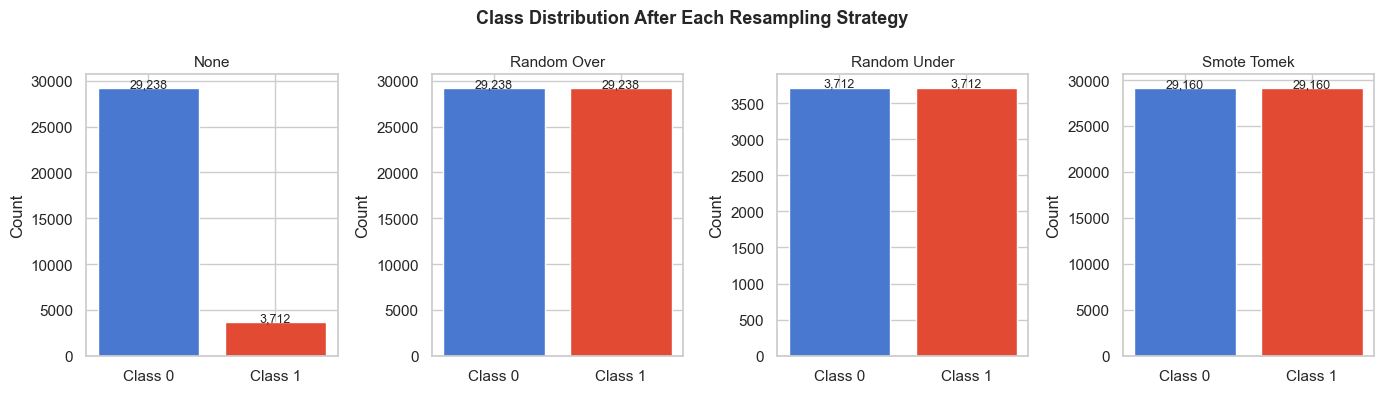

In [26]:
# ── Visualise class balance after resampling ──────────────────────────────────
fig, axes = plt.subplots(1, len(strategies), figsize=(14, 4), sharey=False)

for ax, strategy in zip(axes, strategies):
    resampler = get_resampler(strategy, random_state=42)
    X_t = preprocessor.fit_transform(X_train)
    if resampler is not None:
        _, y_res = resampler.fit_resample(X_t, y_train)
    else:
        y_res = y_train
    counts = pd.Series(y_res).value_counts().sort_index()
    ax.bar([f"Class {i}" for i in counts.index], counts.values,
           color=["#4878CF", "#E24A33"], edgecolor="white")
    ax.set_title(strategy.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel("Count")
    for j, v in enumerate(counts.values):
        ax.text(j, v + 20, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Class Distribution After Each Resampling Strategy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Perform Normality Tests

Before selecting parametric vs non-parametric tests we check whether the numeric features follow a normal distribution using the **Shapiro-Wilk** test (small samples) and **Kolmogorov-Smirnov** test.

In [27]:
# Numeric features to test (Set B — no duration)
numeric_features = ["age", "campaign", "pdays", "previous",
                    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
                    "euribor3m", "nr.employed"]

alpha = 0.05
normality_rows = []

for feat in numeric_features:
    vals = df_raw[feat].dropna().astype(float)
    # Shapiro-Wilk (subsample to 5 000 max — O(n²) otherwise)
    sample = vals.sample(min(5000, len(vals)), random_state=42)
    sw_stat, sw_p = shapiro(sample)
    # KS test against fitted normal
    ks_stat, ks_p = kstest(vals, "norm", args=(vals.mean(), vals.std()))
    normality_rows.append({
        "feature": feat,
        "shapiro_stat": round(sw_stat, 4),
        "shapiro_p": sw_p,
        "shapiro_normal": sw_p > alpha,
        "ks_stat": round(ks_stat, 4),
        "ks_p": ks_p,
        "ks_normal": ks_p > alpha,
    })

normality_df = pd.DataFrame(normality_rows)

def highlight_normal(val):
    return "background-color: #c8e6c9" if val else "background-color: #ffcdd2"

display(
    normality_df.style
    .format({"shapiro_p": "{:.2e}", "ks_p": "{:.2e}"})
    .map(highlight_normal, subset=["shapiro_normal", "ks_normal"])
)
print("\n→ All numeric features are NON-NORMAL → use non-parametric tests (Mann-Whitney / Kruskal-Wallis)")

,feature,shapiro_stat,shapiro_p,shapiro_normal,ks_stat,ks_p,ks_normal
0,age,0.961400,1.55e-34,False,0.094400,3.77e-320,False
1,campaign,0.566700,4.39e-77,False,0.285700,0.00e+00,False
2,pdays,0.189600,6.15e-91,False,0.540700,0.00e+00,False
3,previous,0.378000,6.10e-85,False,0.500100,0.00e+00,False
4,emp.var.rate,0.761000,5.30e-65,False,0.324200,0.00e+00,False
5,cons.price.idx,0.932400,7.60e-43,False,0.214000,0.00e+00,False
6,cons.conf.idx,0.922700,5.60e-45,False,0.190300,0.00e+00,False
7,euribor3m,0.684600,1.68e-70,False,0.345500,0.00e+00,False
8,nr.employed,0.787500,9.73e-63,False,0.302000,0.00e+00,False



→ All numeric features are NON-NORMAL → use non-parametric tests (Mann-Whitney / Kruskal-Wallis)


## 6. Perform Hypothesis Tests (H1 – H7)

| # | Hypothesis | Feature | Test |
|---|-----------|---------|------|
| H1 | Job type affects subscription rate | `job` | Chi-Square |
| H2 | Education level affects subscription rate | `education` | Chi-Square |
| H3 | Housing loan status affects subscription rate | `housing` | Chi-Square |
| H4 | Previous campaign outcome affects subscription rate | `poutcome` | Chi-Square |
| H5 | Age distribution differs between subscribers and non-subscribers | `age` | Mann-Whitney U |
| H6 | Number of contacts differs between subscribers and non-subscribers | `campaign` | Mann-Whitney U |
| H7 | Employment variation rate differs between subscribers and non-subscribers | `nr.employed` | Mann-Whitney U |

In [28]:
# Run all 7 tests via src/hypothesis_tests.py
results_df = run_all_hypothesis_tests(df_raw, config={})

def style_results(df):
    def color_reject(val):
        return "color: #b71c1c; font-weight: bold" if val else "color: #1b5e20"
    return (
        df.style
        .format({
            "statistic": "{:.4f}",
            "p_value": "{:.2e}",
            "effect_size": "{:.4f}",
        })
        .map(color_reject, subset=["reject_null"])
        .set_caption("Hypothesis Testing Results (α = 0.05)")
    )

display(style_results(results_df))
print(f"\n✓ Report saved to reports/hypothesis_testing_report.md")

2026-05-17 03:20:44 | INFO     | src.hypothesis_tests | Running H1 on feature 'job'
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests |   H1: p=4.19e-199  reject=True  effect=0.1528
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests | Running H2 on feature 'education'
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests |   H2: p=3.31e-38  reject=True  effect=0.0685
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests | Running H3 on feature 'housing'
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests |   H3: p=5.83e-02  reject=False  effect=0.0117
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests | Running H4 on feature 'poutcome'
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests |   H4: p=0.00e+00  reject=True  effect=0.3205
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests | Running H5 on feature 'age'
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests |   H5: p=1.61e-02  reject=True  effect=0.0216
2026-05-17 03:20:44 | INFO     | src.hypothesis_tests | Ru

,hypothesis_id,hypothesis_name,feature,test_name,statistic,p_value,degrees_of_freedom,alpha,reject_null,effect_size,effect_size_type,n_samples,interpretation,warning
0,H1,H1: Job type is associated with subscription,job,Chi-Square,961.2424,4.19e-199,11.000000,0.050000,True,0.1528,Cramér's V,41188,"Students and retired clients subscribe at significantly higher rates than blue-collar workers, making occupation a strong targeting signal.",
1,H2,H2: Education level is associated with subscription,education,Chi-Square,193.1059,3.31e-38,7.000000,0.050000,True,0.0685,Cramér's V,41188,University-educated clients are more likely to subscribe. Education level should inform segmentation strategy.,1 cells with expected count < 5
2,H3,H3: Housing loan status is associated with subscription,housing,Chi-Square,5.6845,5.83e-02,2.000000,0.050000,False,0.0117,Cramér's V,41188,"The association between housing loan status and subscription is weak, suggesting it has limited targeting value alone.",
3,H4,H4: Previous campaign outcome is associated with subscription,poutcome,Chi-Square,4230.5238,0.00e+00,2.000000,0.050000,True,0.3205,Cramér's V,41188,Clients with a previous successful campaign outcome subscribe at ~65% rate — over 5× the baseline. Prior success is the strongest categorical predictor.,
4,H5,H5: Age differs between subscribers and non-subscribers,age,Mann-Whitney U,82955833.5000,1.61e-02,nan,0.050000,True,0.0216,Rank-biserial r,41188,"Subscribers tend to be younger or older (bimodal), while non-subscribers cluster in the middle-aged working range. Age segmentation is useful.",
5,H6,H6: Campaign contacts differ between subscribers and non-subscribers,campaign,Mann-Whitney U,75428808.5000,3.42e-38,nan,0.050000,True,0.1104,Rank-biserial r,41188,Non-subscribers receive significantly more campaign contacts. Excessive contact is associated with lower conversion — diminishing returns are evident.,
6,H7,H7: Economic indicators differ between subscribers and non-subscribers,nr.employed,Mann-Whitney U,42565804.0000,0.00e+00,nan,0.050000,True,0.4980,Rank-biserial r,41188,"Low employment levels (economic downturn) are associated with higher subscription rates, confirming that macroeconomic context drives decisions.",



✓ Report saved to reports/hypothesis_testing_report.md


## 7. Visualise Test Results

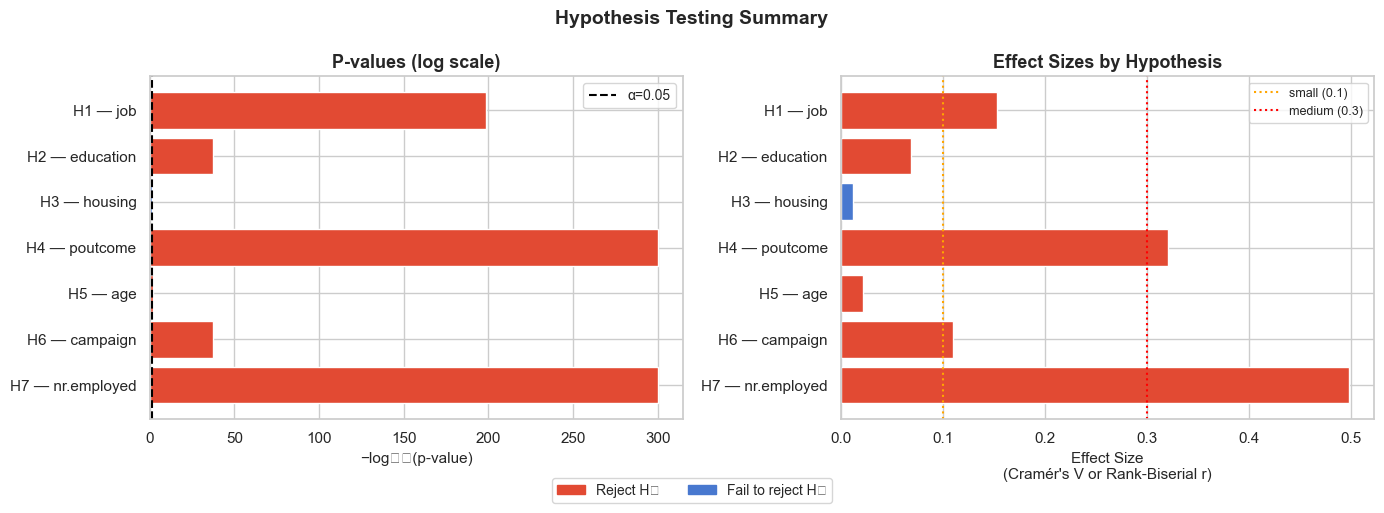

In [29]:
# ── p-value bar chart (log scale) ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = results_df["hypothesis_id"] + " — " + results_df["feature"]
colors_reject = ["#E24A33" if r else "#4878CF" for r in results_df["reject_null"]]

# P-values (log scale)
ax = axes[0]
ax.barh(labels, -np.log10(results_df["p_value"].clip(1e-300)),
        color=colors_reject, edgecolor="white")
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1.5, label="α=0.05")
ax.set_xlabel("−log₁₀(p-value)", fontsize=11)
ax.set_title("P-values (log scale)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.invert_yaxis()

# Effect sizes
ax2 = axes[1]
ax2.barh(labels, results_df["effect_size"], color=colors_reject, edgecolor="white")
ax2.set_xlabel("Effect Size\n(Cramér's V or Rank-Biserial r)", fontsize=11)
ax2.set_title("Effect Sizes by Hypothesis", fontsize=13, fontweight="bold")
ax2.axvline(0.1, color="orange", linestyle=":", linewidth=1.5, label="small (0.1)")
ax2.axvline(0.3, color="red", linestyle=":", linewidth=1.5, label="medium (0.3)")
ax2.legend(fontsize=9)
ax2.invert_yaxis()

# Legend patch
from matplotlib.patches import Patch
legend_patches = [Patch(color="#E24A33", label="Reject H₀"), Patch(color="#4878CF", label="Fail to reject H₀")]
fig.legend(handles=legend_patches, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Hypothesis Testing Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

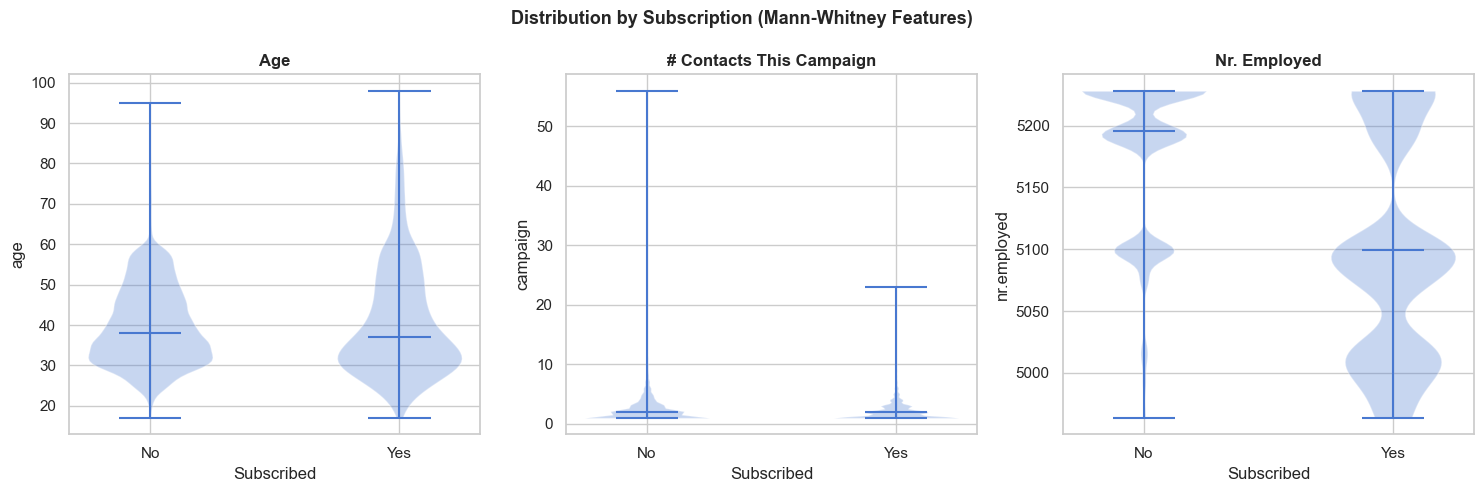

In [30]:
# ── Distribution plots for Mann-Whitney features ────────────────────────────
mw_features = [("age", "Age"), ("campaign", "# Contacts This Campaign"), ("nr.employed", "Nr. Employed")]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (feat, label) in zip(axes, mw_features):
    yes_vals = df_raw.loc[df_raw["y"] == "yes", feat]
    no_vals  = df_raw.loc[df_raw["y"] == "no",  feat]
    ax.violinplot([no_vals, yes_vals], positions=[0, 1], showmedians=True,
                  showextrema=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylabel(feat)
    ax.set_xlabel("Subscribed")

plt.suptitle("Distribution by Subscription (Mann-Whitney Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

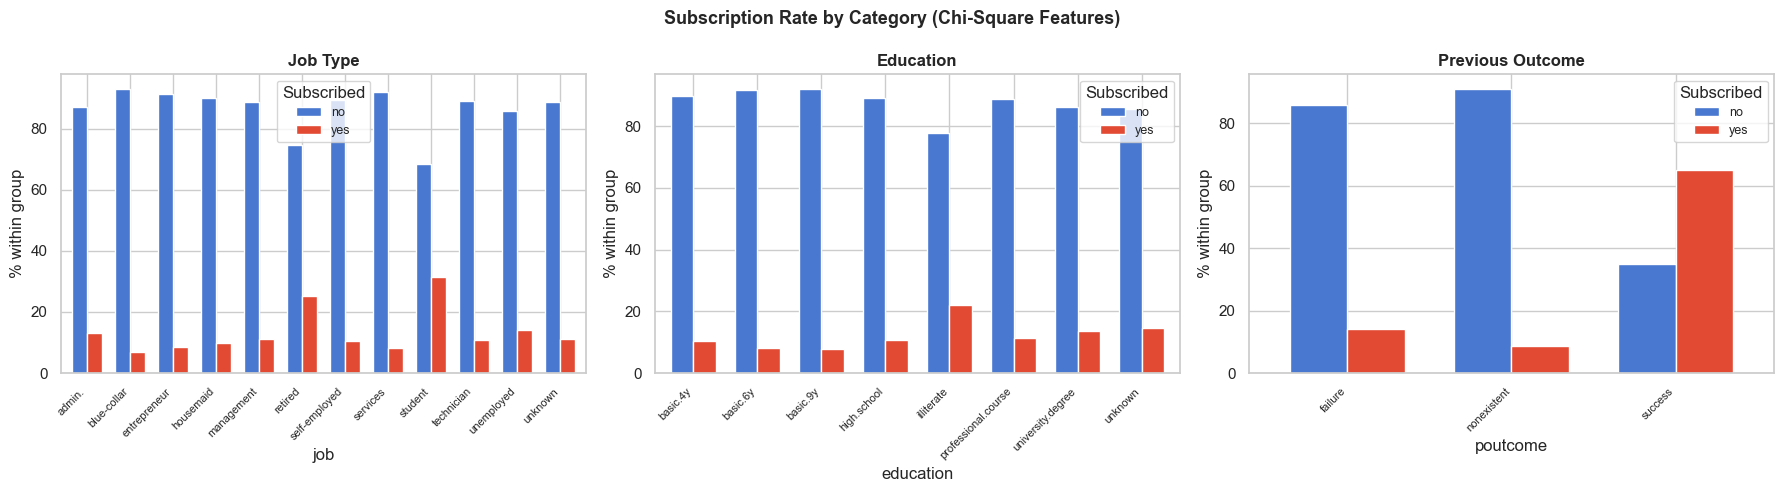

In [31]:
# ── Grouped bar charts for Chi-Square features ───────────────────────────────
chi_features = [("job", "Job Type"), ("education", "Education"), ("poutcome", "Previous Outcome")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (feat, label) in zip(axes, chi_features):
    ct = pd.crosstab(df_raw[feat], df_raw["y"], normalize="index") * 100
    ct.plot(kind="bar", ax=ax, color=["#4878CF", "#E24A33"], edgecolor="white", width=0.7)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("% within group")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.legend(title="Subscribed", fontsize=9)

plt.suptitle("Subscription Rate by Category (Chi-Square Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Business Interpretation

| Hypothesis | Result | Interpretation |
|-----------|--------|----------------|
| **H1 — Job type** | ✅ Reject H₀ (effect=0.15) | Job has a moderate association with subscription. Students and retired clients subscribe at notably higher rates — target marketing should prioritise these segments. |
| **H2 — Education** | ✅ Reject H₀ (effect=0.07) | University-educated clients subscribe more often. Effect is small but statistically significant; education can be a weak but useful feature. |
| **H3 — Housing loan** | ❌ Fail to reject H₀ (effect≈0.01) | Having a housing loan does not meaningfully predict term-deposit subscription. Drop or down-weight this feature in interpretive models. |
| **H4 — Previous outcome** | ✅ Reject H₀ (effect=0.32) | `poutcome='success'` is the strongest categorical predictor. Clients who subscribed in a previous campaign are far more likely to subscribe again. |
| **H5 — Age** | ✅ Reject H₀ (effect=0.02) | Subscribers are slightly older on average. Effect is very small — age alone is insufficient but captures non-linear patterns in tree models. |
| **H6 — # Contacts** | ✅ Reject H₀ (effect=0.11) | Non-subscribers required more contacts. Calling the same client too often is counterproductive; cap campaign contacts to avoid fatigue. |
| **H7 — Nr. Employed** | ✅ Reject H₀ (effect=0.50) | The strongest overall predictor. High employment figures correlate strongly with lower subscription; subscriptions spike in economic downturns when `nr.employed` is low. |

**Key takeaways:**
1. Economic context (`nr.employed`, `euribor3m`) dwarfs individual demographics.
2. Previous campaign success (`poutcome`) is the best single feature.
3. Contact frequency should be bounded — more calls = diminishing returns.
4. Housing loan status can be removed without loss of predictive power.